In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import random
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os

import time
import numpy as np
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

from scipy.ndimage import minimum_filter
from scipy.ndimage import label
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [2]:
def prepare_mnist_with_grey_dots_cpu(
    mat_path,
    class_ratio=0.5,
    split_ratios={'train': 0.7, 'val': 0.15, 'test': 0.15},
    seed=42,
    dot_params=None
):
    np.random.seed(seed)

    # --- Load data ---
    data = loadmat(mat_path)
    X = data['data'].T  # (n_samples, 784)
    y = data['label'].flatten()

    # --- Reduce dataset size by class ---
    X_subset, y_subset = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        n_select = int(len(idx) * class_ratio)
        selected_idx = np.random.choice(idx, n_select, replace=False)
        X_subset.append(X[selected_idx])
        y_subset.append(y[selected_idx])
    X = np.concatenate(X_subset)
    y = np.concatenate(y_subset)

    # --- Shuffle ---
    X, y = shuffle(X, y, random_state=seed)

    # --- Stratified split ---
    train_ratio = split_ratios['train']
    val_ratio = split_ratios['val'] / (split_ratios['val'] + split_ratios['test'])

    X_train, X_rest, y_train, y_rest = train_test_split(
        X, y, train_size=train_ratio, stratify=y, random_state=seed)
    X_val, X_test, y_val, y_test = train_test_split(
        X_rest, y_rest, train_size=val_ratio, stratify=y_rest, random_state=seed)

    # --- Add grey dots + record their positions ---
    def add_grey_dots_np(X_np):
        X_mod = X_np.copy().reshape(-1, 28, 28)
        N = X_mod.shape[0]
        dot_locations = []

        # Convert image to strict black-and-white
        X_strict = np.where(X_mod > 50, 255, 0).astype(np.uint8)
        bright_pixels = [np.argwhere(img == 255) for img in X_strict]

        for i in range(N):
            coords = bright_pixels[i]
            if coords.size == 0:
                dot_locations.append(None)
                continue

            # --- Location ---
            if dot_params and dot_params.get('location') is not None:
                y_dot, x_dot = dot_params['location']
            else:
                y_dot, x_dot = coords[np.random.randint(len(coords))]

            # --- Radius (size) ---
            if dot_params and dot_params.get('radius') is not None:
                radius = int(dot_params['radius'])
            else:
                radius = np.random.randint(1, 3)

            # --- Intensity ---
            if dot_params and dot_params.get('gray') is not None:
                gray = int(dot_params['gray'])
            else:
                gray = np.random.randint(100, 181)

            # --- Apply circular grey dot ---
            y_min = max(y_dot - radius, 0)
            y_max = min(y_dot + radius, 27)
            x_min = max(x_dot - radius, 0)
            x_max = min(x_dot + radius, 27)

            ys, xs = np.ogrid[y_min:y_max+1, x_min:x_max+1]
            dist_sq = (ys - y_dot)**2 + (xs - x_dot)**2
            mask = dist_sq <= radius**2

            X_mod[i, y_min:y_max+1, x_min:x_max+1][mask] = gray

            # Save location
            dot_locations.append({
                'y': int(y_dot),
                'x': int(x_dot),
                'radius': int(radius),
                'gray': int(gray)
            })

        return X_mod.reshape(-1, 784).astype(np.uint8), dot_locations
    # --- Save original images before modifying ---
    X_train_orig = X_train.copy()
    X_val_orig   = X_val.copy()
    X_test_orig  = X_test.copy()
    # Apply grey dot addition
    X_train, dots_train = add_grey_dots_np(X_train)
    X_val, dots_val = add_grey_dots_np(X_val)
    X_test, dots_test = add_grey_dots_np(X_test)

    # Return dictionary with original images added
    return {
        'train': {'X': X_train, 'X_orig': X_train_orig, 'y': y_train, 'dots': dots_train},
        'val':   {'X': X_val,   'X_orig': X_val_orig,   'y': y_val,   'dots': dots_val},
        'test':  {'X': X_test,  'X_orig': X_test_orig,  'y': y_test,  'dots': dots_test}
    }


In [3]:
class InMemoryMNISTDataset(Dataset):
    def __init__(self, X, y, dots=None, X_orig=None, transform=None,
                 return_dot_info=False, return_index=False, return_orig=False):
        self.X = X
        self.y = y
        self.dots = dots
        self.X_orig = X_orig
        self.transform = transform
        self.return_dot_info = return_dot_info
        self.return_index = return_index
        self.return_orig = return_orig

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.y[idx]

        # --- Original image ---
        image_orig = self.X_orig[idx] if self.X_orig is not None else None

        # --- Ensure shape ---
        if image.ndim == 1:
            image = image.reshape(28, 28)
        if image_orig is not None and image_orig.ndim == 1:
            image_orig = image_orig.reshape(28, 28)

        # --- Convert to PIL ---
        image = transforms.functional.to_pil_image(image)
        if image_orig is not None:
            image_orig = transforms.functional.to_pil_image(image_orig)

        if self.transform:
            image = self.transform(image)
            if image_orig is not None:
                # Optionally transform original the same way
                image_orig = self.transform(image_orig)

        # --- Build output tuple ---
        out = [image, label]
        if self.return_orig and image_orig is not None:
            out.append(image_orig)
        if self.return_dot_info and self.dots is not None:
            out.append(self.dots[idx])
        if self.return_index:
            out.append(idx)

        return tuple(out)


In [4]:
# ============================================
# Load MNIST with optional grey dot anomalies
# ============================================
splits = prepare_mnist_with_grey_dots_cpu(
    mat_path="/home/blayne/mnist-original.mat",
    class_ratio=0.7,
    split_ratios={'train': 0.7, 'val': 0.15, 'test': 0.15},
    seed=42
)

# ============================================
# Define transforms
# ============================================
base_transform = transforms.Compose([
    #transforms.RandomRotation(15),
    #transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5], std=[0.5])
])

# ============================================
# Wrap into PyTorch Datasets (with original images)
# ============================================

train_dataset = InMemoryMNISTDataset(
    X=splits['train']['X'],
    X_orig=splits['train']['X_orig'],      # <-- original images
    y=splits['train']['y'],
    dots=splits['train']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True                        # <-- return original image
)

val_dataset = InMemoryMNISTDataset(
    X=splits['val']['X'],
    X_orig=splits['val']['X_orig'],
    y=splits['val']['y'],
    dots=splits['val']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True
)

test_dataset = InMemoryMNISTDataset(
    X=splits['test']['X'],
    X_orig=splits['test']['X_orig'],
    y=splits['test']['y'],
    dots=splits['test']['dots'],
    transform=base_transform,
    return_dot_info=True,
    return_index=True,
    return_orig=True
)

# ============================================
# Optimized DataLoaders
# ============================================

train_loader = DataLoader(
    train_dataset, batch_size=128, shuffle=True,
    num_workers=6, pin_memory=True, persistent_workers=True
)

val_loader = DataLoader(
    val_dataset, batch_size=128, shuffle=False,
    num_workers=6, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    test_dataset, batch_size=128, shuffle=False,
    num_workers=4, pin_memory=False, persistent_workers=False
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 34297, Val: 7349, Test: 7350


In [5]:
def show_sample_images_pair(dataset, num_samples=10):
    """
    Display paired samples from a dataset that returns both (modified, original).

    Top row: modified images (with grey dots)
    Bottom row: original MNIST images
    """
    indices = random.sample(range(len(dataset)), num_samples)
    plt.figure(figsize=(15, 4))

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # --- Unpack modified image and label ---
        image_mod = sample[0]      # modified image (with grey dot)
        label = sample[1]

        # --- Extract original image ---
        image_orig = None
        if len(sample) > 2:
            # Case 1: X_orig stored as a dict
            if isinstance(sample[2], dict) and 'X_orig' in sample[2]:
                image_orig = sample[2]['X_orig']
            else:
                image_orig = sample[2]

        # --- Convert modified image to numpy ---
        if isinstance(image_mod, Image.Image):
            image_mod = np.array(image_mod).astype(np.float32) / 255.0
        elif isinstance(image_mod, torch.Tensor):
            image_mod = image_mod.squeeze().cpu().numpy()

        # --- Convert original image to numpy ---
        if image_orig is not None:
            if isinstance(image_orig, Image.Image):
                image_orig = np.array(image_orig).astype(np.float32) / 255.0
            elif isinstance(image_orig, torch.Tensor):
                image_orig = image_orig.squeeze().cpu().numpy()
            elif isinstance(image_orig, np.ndarray):
                image_orig = image_orig.astype(np.float32)
            else:
                # fallback: convert to array if possible
                try:
                    image_orig = np.array(image_orig).astype(np.float32)
                except:
                    raise TypeError(f"Unsupported type for original image: {type(image_orig)}")

        # --- Plot modified (top row) ---
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(image_mod, cmap='gray', vmin=0, vmax=1)
        plt.title(f"Modified {idx}")
        plt.axis("off")

        # --- Plot original (bottom row) ---
        if image_orig is not None:
            plt.subplot(2, num_samples, i + 1 + num_samples)
            plt.imshow(image_orig, cmap='gray', vmin=0, vmax=1)
            plt.title(f"Original {idx}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


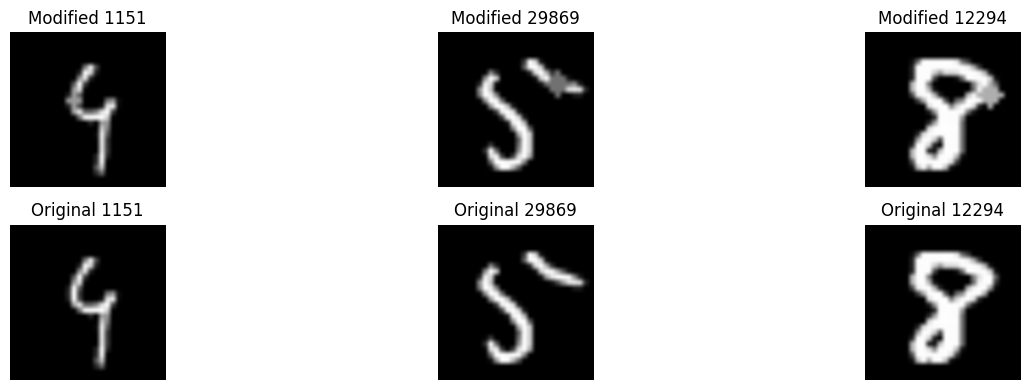

In [6]:
show_sample_images_pair(train_dataset, num_samples=3)
# Example usage:


In [7]:
def show_sample_images_2(dataset, num_samples=10, title='Modified Images'):
    plt.figure(figsize=(num_samples * 1.5, 2))
    indices = torch.randperm(len(dataset))[:num_samples]

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # Defensive unpacking
        img = sample[0]
        label = sample[1]
        image_orig = sample[2] if len(sample) > 2 else None
        dot_info = sample[3] if len(sample) > 3 else None
        sample_idx = sample[4] if len(sample) > 4 else None

        if isinstance(img, torch.Tensor):
            img = img.squeeze().numpy()

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')

        # Overlay the anomaly location (scaled)
        if dot_info is not None:
            scale = img.shape[0] / 28  # dynamic scale
            y = dot_info['y'] * scale
            x = dot_info['x'] * scale
            radius = dot_info['radius'] * scale / 2
            plt.scatter(x, y, s=(radius * 8)**2, edgecolor='red', facecolor='none', linewidths=1.5)

        plt.axis('off')
        plt.title(str(int(label)), fontsize=10)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

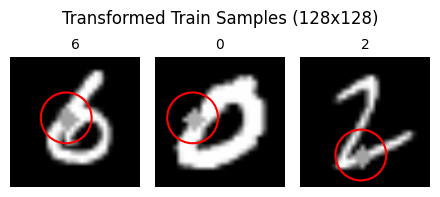

In [8]:
show_sample_images_2(train_dataset, num_samples=3, title="Transformed Train Samples (128x128)")

In [9]:
def random_mask_v5_opt1(
    x, 
    grey_dot_coords=None,
    mask_ratio=0.5,      
    patch_size=8, 
    block_size=3,      
    threshold=0.01, 
    dot_space='28',     # <---- new
    debug=False
):
    B, C, H, W = x.shape
    masks = torch.ones_like(x)
    n_h, n_w = H // patch_size, W // patch_size

    for b in range(B):
        # --- Use stored grey dot info if available ---
        if grey_dot_coords is not None and b < len(grey_dot_coords) and grey_dot_coords[b] is not None:
            info = grey_dot_coords[b]
            y_dot = info.get('y', None)
            x_dot = info.get('x', None)
            radius = info.get('radius', 2)

            # --- Convert to scalar if needed ---
            def to_scalar(val):
                if isinstance(val, (np.ndarray, torch.Tensor)):
                    return int(val.flatten()[0])
                else:
                    return int(val)
            y_dot = to_scalar(y_dot)
            x_dot = to_scalar(x_dot)
            radius = to_scalar(radius)
        else:
            # fallback: random patch
            y_dot = np.random.randint(H)
            x_dot = np.random.randint(W)
            radius = 2

        # --- Scale coordinates only if they’re from 28x28 space ---
        if dot_space == '28':
            scale = H / 28
            y_dot = int(y_dot * scale)
            x_dot = int(x_dot * scale)

        # --- Mask patch block around dot ---
        patch_y = y_dot // patch_size
        patch_x = x_dot // patch_size
        half_block = block_size // 2
        start_y = max(0, patch_y - half_block)
        end_y = min(n_h, patch_y + half_block + 1)
        start_x = max(0, patch_x - half_block)
        end_x = min(n_w, patch_x + half_block + 1)
        
        h_start, h_end = start_y * patch_size, end_y * patch_size
        w_start, w_end = start_x * patch_size, end_x * patch_size

        masks[b, :, h_start:h_end, w_start:w_end] = 0

        if debug:
            print(f"[Batch {b}] dot=({y_dot},{x_dot}), mask block y=({h_start}:{h_end}), x=({w_start}:{w_end})")

    return x * masks, masks


In [10]:
def show_sample_with_mask(dataset, mask_fn, num_samples=5, patch_size=16, title="Masked Images", debug=False):
    """
    Display images from the dataset with a mask applied around grey-dot anomalies.

    Args:
        dataset: InMemoryMNISTDataset instance
        mask_fn: function(x, grey_dot_coords, patch_size, debug) -> masked_x, mask
        num_samples: number of images to display
        patch_size: size of the square patch to mask
        title: figure title
        debug: if True, print debug info from mask_fn
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    plt.figure(figsize=(num_samples * 3, 3))

    indices = torch.randperm(len(dataset))[:num_samples]

    for i, idx in enumerate(indices):
        sample = dataset[idx]

        # --- Unpack sample ---
        img        = sample[0]
        label      = sample[1]
        dot_info   = sample[3] if len(sample) > 3 else None

        # --- Convert to tensor with batch dimension ---
        if isinstance(img, np.ndarray):
            img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
        elif isinstance(img, torch.Tensor):
            img_tensor = img.unsqueeze(0) if img.ndim == 3 else img.unsqueeze(0).unsqueeze(0)
        img_tensor = img_tensor.to(device)

        # --- Prepare grey-dot dict for masking ---
        dot_dict = dot_info if isinstance(dot_info, dict) else None

        # --- Apply mask function ---
        masked_img, _ = mask_fn(
            img_tensor,
            grey_dot_coords=[dot_dict],
            patch_size=patch_size,
            debug=debug
        )

        # --- Convert to CPU numpy for plotting ---
        img_np = img_tensor[0, 0].cpu().numpy()
        masked_np = masked_img[0, 0].cpu().numpy()

        # --- Plot original image ---
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img_np, cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis('off')

        # --- Plot masked image ---
        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(masked_np, cmap='gray')
        plt.axis('off')

        # --- Overlay smaller red circle ---
        if dot_dict is not None:
            scale = img_np.shape[0] / 28
            y = dot_dict['y'] * scale
            x = dot_dict['x'] * scale
            radius = 1.5  # smaller radius for visualization

            plt.subplot(2, num_samples, i + 1)
            plt.scatter(x, y, s=(radius*8)**2, edgecolor='red', facecolor='none', linewidths=1.2)
            plt.subplot(2, num_samples, i + 1 + num_samples)
            plt.scatter(x, y, s=(radius*8)**2, edgecolor='red', facecolor='none', linewidths=1.2)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


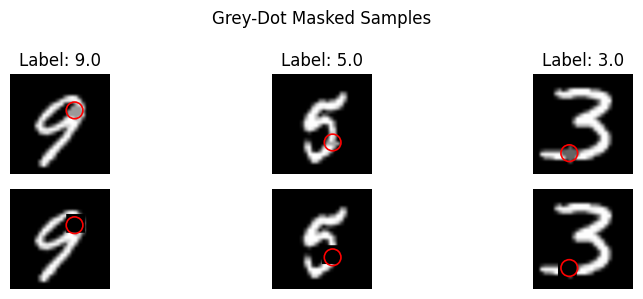

In [11]:
show_sample_with_mask(train_dataset, random_mask_v5_opt1, num_samples=3, patch_size=8, title="Grey-Dot Masked Samples")

In [12]:
# -----------------------------
# Lightweight Residual Block
# -----------------------------
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.GroupNorm(4, channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.GroupNorm(4, channels),
        )

    def forward(self, x):
        return F.gelu(x + self.block(x))


# -----------------------------
# Encoder
# -----------------------------
class Encoder(nn.Module):
    def __init__(self, latent_dim=256, input_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),   # 128 → 64
            nn.GroupNorm(4, 32),
            nn.GELU(),
            ResidualBlock(32),

            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 64 → 32
            nn.GroupNorm(8, 64),
            nn.GELU(),

            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 32 → 16
            nn.GroupNorm(8, 128),
            nn.GELU(),
            ResidualBlock(128),

            nn.Conv2d(128, 256, 4, stride=2, padding=1), # 16 → 8
            nn.GroupNorm(16, 256),
            nn.GELU(),
        )

        self.flatten = nn.Flatten()
        self.feature_map_size = input_size // 16
        self.fc = nn.Linear(256 * self.feature_map_size ** 2, latent_dim)

    def forward(self, x):
        x = self.net(x)
        z = self.fc(self.flatten(x))
        return z


# -----------------------------
# Decoder
# -----------------------------
class Decoder(nn.Module):
    def __init__(self, latent_dim=256, feature_map_size=8):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * feature_map_size * feature_map_size)
        self.feature_map_size = feature_map_size

        self.up = nn.Sequential(
            ResidualBlock(256),   # extra expressivity for reconstruction

            # 8 → 16
            nn.Conv2d(256, 128 * 4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.GELU(),

            # 16 → 32
            nn.Conv2d(128, 64 * 4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.GELU(),

            # 32 → 64
            nn.Conv2d(64, 32 * 4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.GELU(),

            # 64 → 128
            nn.Conv2d(32, 1 * 4, 3, padding=1),
            nn.PixelShuffle(2),
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, self.feature_map_size, self.feature_map_size)
        return self.up(x)


# -----------------------------
# Masked Autoencoder
# -----------------------------
class MaskedAutoencoder(nn.Module):
    def __init__(self, latent_dim=256, input_size=128):
        super().__init__()
        self.encoder = Encoder(latent_dim=latent_dim, input_size=input_size)
        self.decoder = Decoder(latent_dim=latent_dim, feature_map_size=input_size // 16)

    def forward(self, x_masked):
        z = self.encoder(x_masked)
        x_rec = self.decoder(z)
        return x_rec


# -----------------------------
# Instantiate
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MaskedAutoencoder(latent_dim=256, input_size=128).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
loss_fn = nn.MSELoss()

In [13]:
print(model)

MaskedAutoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): GroupNorm(4, 32, eps=1e-05, affine=True)
      (2): GELU(approximate='none')
      (3): ResidualBlock(
        (block): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): GroupNorm(4, 32, eps=1e-05, affine=True)
          (2): GELU(approximate='none')
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (4): GroupNorm(4, 32, eps=1e-05, affine=True)
        )
      )
      (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): GroupNorm(8, 64, eps=1e-05, affine=True)
      (6): GELU(approximate='none')
      (7): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (8): GroupNorm(8, 128, eps=1e-05, affine=True)
      (9): GELU(approximate='none')
      (10): ResidualBlock(
  

In [14]:
# -------------------------------------------------
# Mask-weighted loss (unchanged)
# -------------------------------------------------
def masked_reconstruction_loss(x_rec, x_orig, mask, weight_masked=2.0):
    """
    Weighted reconstruction loss that emphasizes masked regions.
    """
    visible = mask
    masked = 1 - mask
    mse = (x_rec - x_orig) ** 2

    loss_visible = (mse * visible).sum() / (visible.sum() + 1e-8)
    loss_masked  = (mse * masked).sum() / (masked.sum() + 1e-8)

    return loss_visible + weight_masked * loss_masked


# -------------------------------------------------
# Training + Evaluation Function (updated)
# -------------------------------------------------
def train_and_evaluate(
    model, train_loader, val_loader,
    n_epochs=10, mask_ratio=0.3, lr=1e-3,
    patience=10, mask_fn=None, patch_size=None,
    block_size=None,              # <-- added block_size
    show_batch_progress=True
):
    """
    Train the model with mask-weighted loss and early stopping.
    Handles grey_dot_coords safely for all batches.
    """
    if mask_fn is None:
        raise ValueError("You must provide a masking function (mask_fn).")

    device = next(model.parameters()).device
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        # -------------------
        # Training
        # -------------------
        model.train()
        total_train_loss = 0
        epoch_start = time.time()

        train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} - Training", leave=False) \
                     if show_batch_progress else train_loader

        for batch in train_iter:
            # --- Normalize grey_dot_coords ---
            if len(batch) == 3:
                x, _ = batch
                grey_dot_coords = [None] * x.size(0)
            else:
                x, _, dot_info = batch[:3]
                B = x.size(0)
                if isinstance(dot_info, dict):
                    grey_dot_coords = [dot_info] + [None]*(B-1)
                elif isinstance(dot_info, (list, tuple)):
                    grey_dot_coords = [
                        di if isinstance(di, dict) else None for di in dot_info
                    ]
                    if len(grey_dot_coords) < B:
                        grey_dot_coords += [None]*(B - len(grey_dot_coords))
                else:
                    grey_dot_coords = [None]*B

            x = x.to(device)
            x_masked, mask = mask_fn(
                x, 
                grey_dot_coords=grey_dot_coords,
                mask_ratio=mask_ratio, 
                patch_size=patch_size,
                block_size=block_size   # <-- pass block_size here
            )
            x_rec = model(x_masked)
            loss = masked_reconstruction_loss(x_rec, x, mask, weight_masked=2.0)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_train_loss += loss.item() * x.size(0)
            if show_batch_progress:
                train_iter.set_postfix({"batch_loss": f"{loss.item():.6f}"})

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # -------------------
        # Validation
        # -------------------
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 3:
                    x, _ = batch
                    grey_dot_coords = [None] * x.size(0)
                else:
                    x, _, dot_info = batch[:3]
                    B = x.size(0)
                    if isinstance(dot_info, dict):
                        grey_dot_coords = [dot_info] + [None]*(B-1)
                    elif isinstance(dot_info, (list, tuple)):
                        grey_dot_coords = [
                            di if isinstance(di, dict) else None for di in dot_info
                        ]
                        if len(grey_dot_coords) < B:
                            grey_dot_coords += [None]*(B - len(grey_dot_coords))
                    else:
                        grey_dot_coords = [None]*B

                x = x.to(device)
                x_masked, mask = mask_fn(
                    x, 
                    grey_dot_coords=grey_dot_coords,
                    mask_ratio=mask_ratio, 
                    patch_size=patch_size,
                    block_size=block_size   # <-- pass block_size here too
                )
                x_rec = model(x_masked)
                loss = masked_reconstruction_loss(x_rec, x, mask, weight_masked=2.0)
                total_val_loss += loss.item() * x.size(0)

        avg_val_loss = total_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch+1}/{n_epochs} | "
              f"Train Loss: {avg_train_loss:.6f} | "
              f"Val Loss: {avg_val_loss:.6f} | "
              f"Time: {epoch_time:.1f}s")

        # -------------------
        # Early Stopping
        # -------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    return best_val_loss, train_losses, val_losses


=== Training | mask_fn=random_mask_v5_opt1, epochs=30, mask=0.2, lr=0.0001, patch_size=8, block_size=7 ===


Epoch 1/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 0.189988 | Val Loss: 0.136281 | Time: 32.7s


Epoch 2/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 2/30 | Train Loss: 0.122353 | Val Loss: 0.108050 | Time: 30.9s


...

Epoch 28/30 | Train Loss: 0.040767 | Val Loss: 0.044910 | Time: 31.5s


Epoch 29/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 0.042781 | Val Loss: 0.047560 | Time: 31.4s


Epoch 30/30 - Training:   0%|          | 0/268 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 0.041249 | Val Loss: 0.042846 | Time: 31.5s
Time for this run: 932.49 seconds
Test MSE: 0.005693


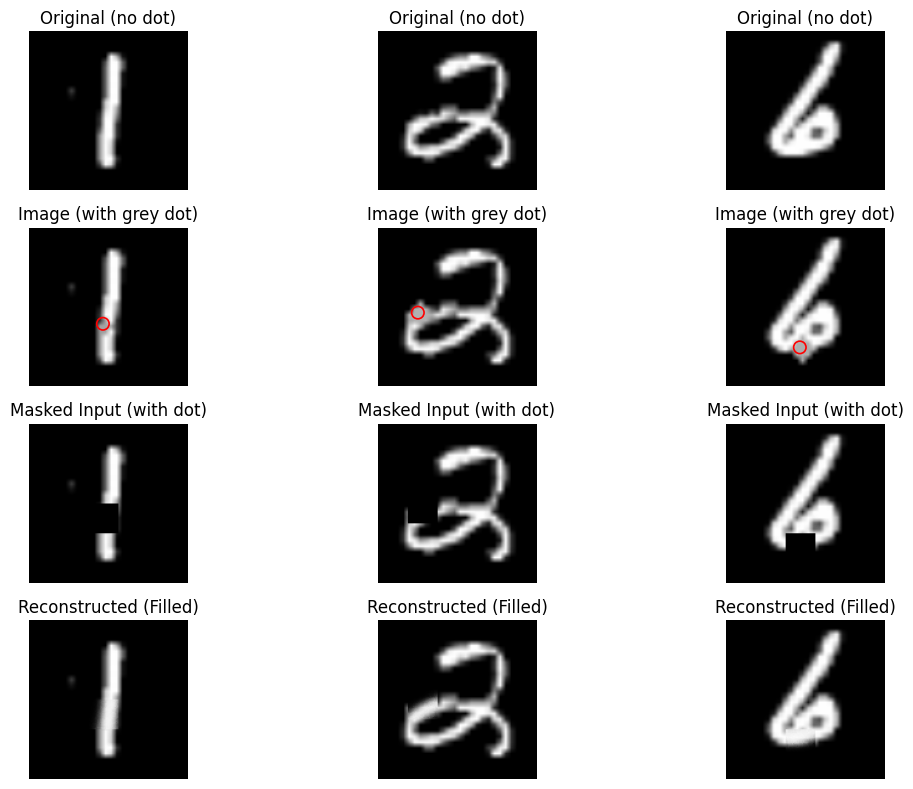

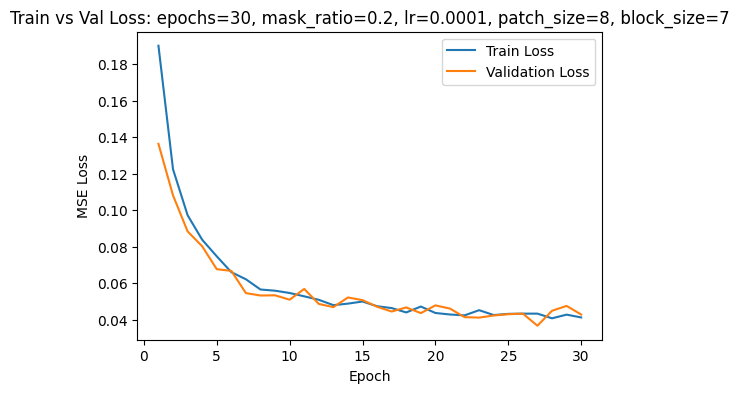

In [15]:
# --- Hyperparameter sweep ---
epoch_options      = [30]                # Number of training epochs
mask_options       = [0.2]
lr_options         = [0.0001]              # Only the missing LR
patch_size_options = [8]              # Keep both patch sizes
block_size_options = [7]                 # Only missing block_sizes for lr=5e-4
mask_fn_options = [
    ("random_mask_v5_opt1", random_mask_v5_opt1),
]



results = []
train_val_curves = {}
test_results = []


def extract_batch_with_orig(batch):
    """
    Return:
      x: tensor (B, C, H, W) — the dataset image (with grey dot present)
      x_orig: tensor or None (B, C, H, W) — original image without dot if available
      grey_dot_coords: list of dicts or None per item
    """
    # Cases:
    # - If dataset returned only (x, y)
    # - If dataset returned (x, y, x_orig, dot_info, idx) or similar.
    if len(batch) == 2:
        x, _ = batch
        x_orig = None
        grey_dot_coords = [None] * x.size(0)
    else:
        # batch may be length >=3
        x = batch[0]
        # try to find x_orig and dot_info robustly
        # typical order in your Dataset: (image, label, image_orig, dots, index)
        x_orig = None
        dot_info = None

        # pick plausible positions
        if len(batch) >= 3:
            # third item could be x_orig or dot_info
            third = batch[2]
            if isinstance(third, (torch.Tensor, np.ndarray, Image.Image)):
                x_orig = third
            elif isinstance(third, dict) or isinstance(third, (list, tuple)):
                dot_info = third

        if len(batch) >= 4:
            fourth = batch[3]
            if x_orig is None and isinstance(fourth, (torch.Tensor, np.ndarray, Image.Image)):
                x_orig = fourth
            elif dot_info is None and (isinstance(fourth, dict) or isinstance(fourth, (list, tuple))):
                dot_info = fourth

        # Build grey_dot_coords list
        B = x.size(0)
        if dot_info is None:
            grey_dot_coords = [None] * B
        elif isinstance(dot_info, dict) and all(isinstance(dot_info.get(k), torch.Tensor) for k in ("y", "x")):
            # batched dict of tensors
            n = dot_info["y"].numel()
            grey_dot_coords = [
                {
                    "y": int(dot_info["y"][i].item()),
                    "x": int(dot_info["x"][i].item()),
                    "radius": int(dot_info.get("radius", torch.tensor(1))[i].item()) if "radius" in dot_info else 1
                }
                for i in range(n)
            ]
            if len(grey_dot_coords) < B:
                grey_dot_coords += [None] * (B - len(grey_dot_coords))
        elif isinstance(dot_info, (list, tuple)):
            grey_dot_coords = [di if isinstance(di, dict) else None for di in dot_info]
            if len(grey_dot_coords) < B:
                grey_dot_coords += [None] * (B - len(grey_dot_coords))
        else:
            # maybe a single dict repeated for whole batch
            if isinstance(dot_info, dict):
                grey_dot_coords = [dot_info] + [None] * (B - 1)
            else:
                grey_dot_coords = [None] * B

        # If x_orig is a single tensor for the whole batch (rare), expand it
        if x_orig is not None and isinstance(x_orig, torch.Tensor) and x_orig.shape[0] != x.shape[0]:
            # try to tile or broadcast if necessary
            try:
                x_orig = x_orig.repeat(x.shape[0], *([1] * (x_orig.dim() - 1)))
            except:
                x_orig = None

    return x, x_orig, grey_dot_coords


# ======================================================
# Main training + evaluation sweep
# ======================================================
for mask_fn_name, mask_fn in mask_fn_options:
    for n_epoch in epoch_options:
        for mask_ratio in mask_options:
            for lr in lr_options:
                for patch_size in patch_size_options:
                    for block_size in block_size_options:  # <-- loop over block_size
                        print("\n" + "=" * 60, flush=True)
                        print(f"=== Training | mask_fn={mask_fn_name}, epochs={n_epoch}, "
                              f"mask={mask_ratio}, lr={lr}, patch_size={patch_size}, block_size={block_size} ===", flush=True)

                        start_time = time.time()

                        # Instantiate a fresh modelimage_size
                        model_copy = MaskedAutoencoder(latent_dim=128).to(device)

                        # Train and evaluate
                        best_val_loss, train_losses, val_losses = train_and_evaluate(
                            model_copy, train_loader, val_loader,
                            n_epochs=n_epoch,
                            mask_ratio=mask_ratio,
                            lr=lr,
                            patience=10,
                            mask_fn=mask_fn,
                            patch_size=patch_size,
                            block_size=block_size     # <-- pass block_size to train_and_evaluate
                        )

                        elapsed = time.time() - start_time
                        print(f"Time for this run: {elapsed:.2f} seconds", flush=True)

                        # Store results
                        results.append({
                            "mask_fn": mask_fn_name,
                            "n_epochs": n_epoch,
                            "mask_ratio": mask_ratio,
                            "lr": lr,
                            "patch_size": patch_size,
                            "block_size": block_size,
                            #"test_mse": test_mse,
                            "val_loss": best_val_loss,
                            "train_time_s": elapsed
                        })
                        train_val_curves[(n_epoch, mask_ratio, lr, patch_size, block_size)] = (train_losses, val_losses)

                        # ======================================================
                        # Test set evaluation (optional)
                        # ======================================================
                        model_copy.eval()
                        mse_loss = nn.MSELoss()
                        test_mse = 0.0

                        with torch.no_grad():
                            for batch in test_loader:
                                x, x_orig, grey_dot_coords = extract_batch_with_orig(batch)
                                x = x.to(device)

                                x_masked, mask = mask_fn(
                                    x,
                                    grey_dot_coords=grey_dot_coords,
                                    mask_ratio=mask_ratio,
                                    patch_size=patch_size,
                                    block_size=block_size  # <-- pass block_size to mask_fn
                                )
                                x_rec = model_copy(x_masked)
                                loss = mse_loss(x_rec * mask, x * mask)
                                test_mse += loss.item() * x.size(0)

                        test_mse /= len(test_loader.dataset)
                        print(f"Test MSE: {test_mse:.6f}")
                # Visual comparison: show original (no dot), masked input (with dot & mask), reconstructed filled
                with torch.no_grad():
                    batch = next(iter(test_loader))
                    x, x_orig, grey_dot_coords = extract_batch_with_orig(batch)

                    # move to device (x_orig may be None)
                    x = x.to(device)
                    if x_orig is not None:
                        x_orig_t = x_orig.to(device)
                    else:
                        x_orig_t = None

                    x_masked, mask = mask_fn(
                        x,
                        grey_dot_coords=grey_dot_coords,
                        mask_ratio=mask_ratio,
                        patch_size=patch_size
                    )
                    x_rec = model_copy(x_masked)

                n_show = 3
                plt.figure(figsize=(12, 8))  # increased height for 4 rows

                for i in range(n_show):
                    # --- Original (no dot) ---
                    if x_orig_t is not None:
                        orig_np = x_orig_t[i, 0].cpu().numpy()
                    else:
                        # fallback: if no original provided, use x (which has the dot)
                        orig_np = x[i, 0].cpu().numpy()

                    # --- Image with grey dot (before masking) ---
                    img_with_dot_np = x[i, 0].cpu().numpy()

                    # --- Masked input (after applying mask) ---
                    masked_np = x_masked[i, 0].cpu().numpy()

                    # --- Reconstruction ---
                    rec_np = x_rec[i, 0].cpu().numpy()

                    # --- Binary mask (1 visible, 0 masked) ---
                    mask_np = mask[i, 0].cpu().numpy()
                    mask_np = (mask_np > 0.5).astype(np.float32)

                    # --- Filled image: combine visible & reconstructed ---
                    filled = masked_np * mask_np + rec_np * (1.0 - mask_np)

                    # ======================================================
                    # 1️⃣ Original (no dot)
                    # ======================================================
                    plt.subplot(4, n_show, i + 1)
                    plt.imshow(orig_np, cmap='gray', vmin=0, vmax=1)
                    plt.title("Original (no dot)")
                    plt.axis("off")

                    # ======================================================
                    # 2️⃣ Image (with grey dot)
                    # ======================================================
                    plt.subplot(4, n_show, i + 1 + n_show)
                    plt.imshow(img_with_dot_np, cmap='gray', vmin=0, vmax=1)
                    plt.title("Image (with grey dot)")
                    plt.axis("off")

                    # Overlay dot marker if available
                    if grey_dot_coords is not None and i < len(grey_dot_coords) and grey_dot_coords[i] is not None:
                        info = grey_dot_coords[i]
                        if info.get('y') is not None and info.get('x') is not None:
                            H = img_with_dot_np.shape[0]
                            scale = H / 28.0
                            y = int(info['y'] * scale)
                            x_ = int(info['x'] * scale)
                            plt.scatter(x_, y, s=80, edgecolors='red', facecolors='none', linewidths=1.2)

                    # ======================================================
                    # 3️⃣ Masked Input (with dot & mask)
                    # ======================================================
                    plt.subplot(4, n_show, i + 1 + 2 * n_show)
                    plt.imshow(masked_np, cmap='gray', vmin=0, vmax=1)
                    plt.title("Masked Input (with dot)")
                    plt.axis("off")

                    # ======================================================
                    # 4️⃣ Reconstructed (filled)
                    # ======================================================
                    plt.subplot(4, n_show, i + 1 + 3 * n_show)
                    plt.imshow(filled, cmap='gray', vmin=0, vmax=1)
                    plt.title("Reconstructed (Filled)")
                    plt.axis("off")

                plt.tight_layout()
                plt.show()


# ======================================================
# Results summary and plots
# ======================================================
df_val = pd.DataFrame(results)
df_test = pd.DataFrame(test_results)

for key, (train_losses, val_losses) in train_val_curves.items():
    n_epoch, mask_ratio, lr, patch_size, block_size = key  # <-- unpack all 5
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
    plt.title(f"Train vs Val Loss: epochs={n_epoch}, mask_ratio={mask_ratio}, lr={lr}, patch_size={patch_size}, block_size={block_size}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()

In [16]:
"""df = pd.DataFrame(results)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_mse_values = []

for idx, row in df.iterrows():
    cfg = dict(row)
    model_name = f"mae_{cfg['mask_fn']}_lr{cfg['lr']}_patch{cfg['patch_size']}_block{cfg['block_size']}.pt"

    try:
        model = MaskedAutoencoder(
            latent_dim=128,
            patch_size=cfg["patch_size"],
            block_size=cfg["block_size"]
        ).to(device)
        model.load_state_dict(torch.load(f"checkpoints/{model_name}", map_location=device))
        model.eval()

        mse_list = []
        with torch.no_grad():
            for batch in test_loader:
                x = batch[0].to(device)
                mask = random_mask_v5_opt1(x, cfg["mask_ratio"]).to(device)
                x_rec = model(x, mask)
                mse = ((x_rec - x) ** 2).mean(dim=[1, 2, 3])
                mse_list.append(mse.cpu())

        test_mse = torch.cat(mse_list).mean().item()
        print(f"[{model_name}] Test MSE = {test_mse:.6f}")
        test_mse_values.append(test_mse)

    except Exception as e:
        print(f"⚠️ Could not evaluate {model_name}: {e}")
        test_mse_values.append(np.nan)

df["Test MSE"] = test_mse_values

# Save updated results
df.to_csv("results_with_test_mse.csv", index=False)
print("\n✅ Updated results saved to results_with_test_mse.csv")"""

'df = pd.DataFrame(results)\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\ntest_mse_values = []\n\nfor idx, row in df.iterrows():\n    cfg = dict(row)\n    model_name = f"mae_{cfg[\'mask_fn\']}_lr{cfg[\'lr\']}_patch{cfg[\'patch_size\']}_block{cfg[\'block_size\']}.pt"\n\n    try:\n        model = MaskedAutoencoder(\n            latent_dim=128,\n            patch_size=cfg["patch_size"],\n            block_size=cfg["block_size"]\n        ).to(device)\n        model.load_state_dict(torch.load(f"checkpoints/{model_name}", map_location=device))\n        model.eval()\n\n        mse_list = []\n        with torch.no_grad():\n            for batch in test_loader:\n                x = batch[0].to(device)\n                mask = random_mask_v5_opt1(x, cfg["mask_ratio"]).to(device)\n                x_rec = model(x, mask)\n                mse = ((x_rec - x) ** 2).mean(dim=[1, 2, 3])\n                mse_list.append(mse.cpu())\n\n        test_mse = torch.cat(mse_list).mean(

In [17]:
"""def summarize_completed_runs(results, test_results=None):
    
    Summarize all completed hyperparameter configurations and their test results.

    Args:
        results (list of dict): Stored configurations and validation results.
        test_results (list of dict or None): Optional list of test MSE entries (may be empty).

    Returns:
        pd.DataFrame: A merged, sorted summary of all configurations and test MSE values.
    
    import pandas as pd
    import numpy as np

    if not results:
        print("No results found — did the sweep complete?")
        return pd.DataFrame()

    df_results = pd.DataFrame(results)
    df_test = pd.DataFrame(test_results) if test_results else pd.DataFrame()

    # Merge test results if available
    if not df_test.empty:
        merged = pd.merge(
            df_results,
            df_test,
            on=["mask_fn", "n_epochs", "mask_ratio", "lr", "patch_size", "block_size"],
            how="outer"
        )
        if "test_mse" in merged.columns:
            merged = merged.rename(columns={"test_mse": "Test MSE"})
    else:
        # No separate test results — use results only
        merged = df_results.copy()
        if "test_mse" not in merged.columns:
            merged["Test MSE"] = np.nan

    # Rename columns for readability
    merged = merged.rename(columns={"val_loss": "Best Val Loss"})

    # Sort ascending by Test MSE if available, else by Best Val Loss
    sort_key = "Test MSE" if merged["Test MSE"].notna().any() else "Best Val Loss"
    merged = merged.sort_values(by=sort_key, ascending=True).reset_index(drop=True)

    # Show clean table
    display(merged[
        ["mask_fn", "n_epochs", "mask_ratio", "lr", "patch_size", "block_size",
         "Best Val Loss", "Test MSE", "train_time_s"]
    ])

    # Optionally highlight best Test MSE row
    if merged["Test MSE"].notna().any():
        best_idx = merged["Test MSE"].idxmin()
        best_cfg = merged.loc[best_idx]
        print("\n🏆 Best configuration (lowest Test MSE):")
        for k, v in best_cfg.items():
            print(f"  {k}: {v}")

    return mergedsummary_df = summarize_completed_runs(results, test_results)

"""

'def summarize_completed_runs(results, test_results=None):\n    \n    Summarize all completed hyperparameter configurations and their test results.\n\n    Args:\n        results (list of dict): Stored configurations and validation results.\n        test_results (list of dict or None): Optional list of test MSE entries (may be empty).\n\n    Returns:\n        pd.DataFrame: A merged, sorted summary of all configurations and test MSE values.\n    \n    import pandas as pd\n    import numpy as np\n\n    if not results:\n        print("No results found — did the sweep complete?")\n        return pd.DataFrame()\n\n    df_results = pd.DataFrame(results)\n    df_test = pd.DataFrame(test_results) if test_results else pd.DataFrame()\n\n    # Merge test results if available\n    if not df_test.empty:\n        merged = pd.merge(\n            df_results,\n            df_test,\n            on=["mask_fn", "n_epochs", "mask_ratio", "lr", "patch_size", "block_size"],\n            how="outer"\n        )

In [20]:
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def evaluate_masked_vae_with_visuals(
    model,
    dataloader,
    mask_fn,
    device,
    patch_size=8,
    n_show=5
):
    """
    Evaluate masked VAE on the test set with visuals:
      - Original (no dot) image with mask box
      - Image with grey dot
      - Reconstructed (filled) image
      - Zoomed-in view: original vs reconstructed masked region
    """
    model.eval()
    mse_loss = nn.MSELoss(reduction='none')
    all_masked_mse = []

    with torch.no_grad():
        batch = next(iter(dataloader))
        x, x_orig, grey_dot_coords = extract_batch_with_orig(batch)

        x = x.to(device)
        if x_orig is not None:
            x_orig_t = x_orig.to(device)
        else:
            x_orig_t = None

        # Apply mask function
        x_masked, mask = mask_fn(
            x,
            grey_dot_coords=grey_dot_coords,
            mask_ratio=0.4,
            patch_size=patch_size
        )
        x_rec = model(x_masked)

        # Compute masked region MSE
        masked_region = (1.0 - mask)
        mse_per_pixel = mse_loss(x_rec, x)
        masked_mse = (mse_per_pixel * masked_region).sum(dim=(1, 2, 3)) / masked_region.sum(dim=(1, 2, 3))
        all_masked_mse.extend(masked_mse.cpu().numpy())

        # ----- Visualisations -----
        n_show = min(n_show, x.size(0))
        plt.figure(figsize=(20, 3 * n_show))  # wider for 4 panels

        for i in range(n_show):
            if x_orig_t is not None:
                orig_np = x_orig_t[i, 0].cpu().numpy()
            else:
                orig_np = x[i, 0].cpu().numpy()

            img_with_dot_np = x[i, 0].cpu().numpy()
            rec_np = x_rec[i, 0].cpu().numpy()
            mask_np = mask[i, 0].cpu().numpy()
            masked_region_np = (mask_np < 0.5).astype(np.uint8)
            masked_np = x_masked[i, 0].cpu().numpy()

            # Full filled image
            filled = masked_np * mask_np + rec_np * (1.0 - mask_np)

            # --- Mask bounding box ---
            ys, xs = np.where(masked_region_np > 0)
            if len(xs) > 0 and len(ys) > 0:
                y_min, y_max = ys.min(), ys.max()
                x_min, x_max = xs.min(), xs.max()
            else:
                y_min = x_min = 0
                y_max = x_max = masked_region_np.shape[0] - 1

            # -----------------------------
            # 1️⃣ Original (no dot)
            # -----------------------------
            plt.subplot(n_show, 4, i * 4 + 1)
            plt.imshow(orig_np, cmap='gray', vmin=0, vmax=1)
            plt.plot([x_min, x_max, x_max, x_min, x_min],
                     [y_min, y_min, y_max, y_max, y_min],
                     color='red', linewidth=1.5)
            plt.title(f"Original (no dot)\nMasked MSE={masked_mse[i]:.4f}")
            plt.axis("off")

            # -----------------------------
            # 2️⃣ Image with grey dot
            # -----------------------------
            plt.subplot(n_show, 4, i * 4 + 2)
            plt.imshow(img_with_dot_np, cmap='gray', vmin=0, vmax=1)
            plt.plot([x_min, x_max, x_max, x_min, x_min],
                     [y_min, y_min, y_max, y_max, y_min],
                     color='red', linewidth=1.5)
            plt.title("Image (with grey dot)")
            plt.axis("off")

            # -----------------------------
            # 3️⃣ Reconstructed (filled)
            # -----------------------------
            plt.subplot(n_show, 4, i * 4 + 3)
            plt.imshow(filled, cmap='gray', vmin=0, vmax=1)
            plt.plot([x_min, x_max, x_max, x_min, x_min],
                     [y_min, y_min, y_max, y_max, y_min],
                     color='red', linewidth=1.5)
            plt.title("Reconstructed (filled)")
            plt.axis("off")

            # -----------------------------
            # 4️⃣ Zoomed-in: original vs reconstructed
            # -----------------------------
            plt.subplot(n_show, 4, i * 4 + 4)
            zoom_orig = orig_np[y_min:y_max, x_min:x_max]
            zoom_rec = filled[y_min:y_max, x_min:x_max]
            # combine side-by-side
            zoom_combined = np.concatenate([zoom_orig, zoom_rec], axis=1)
            plt.imshow(zoom_combined, cmap='gray', vmin=0, vmax=1)
            plt.title("Zoom: original | reconstructed")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    mean_mse = np.nanmean(all_masked_mse)
    print(f"Average masked region MSE: {mean_mse:.6f}")
    return mean_mse


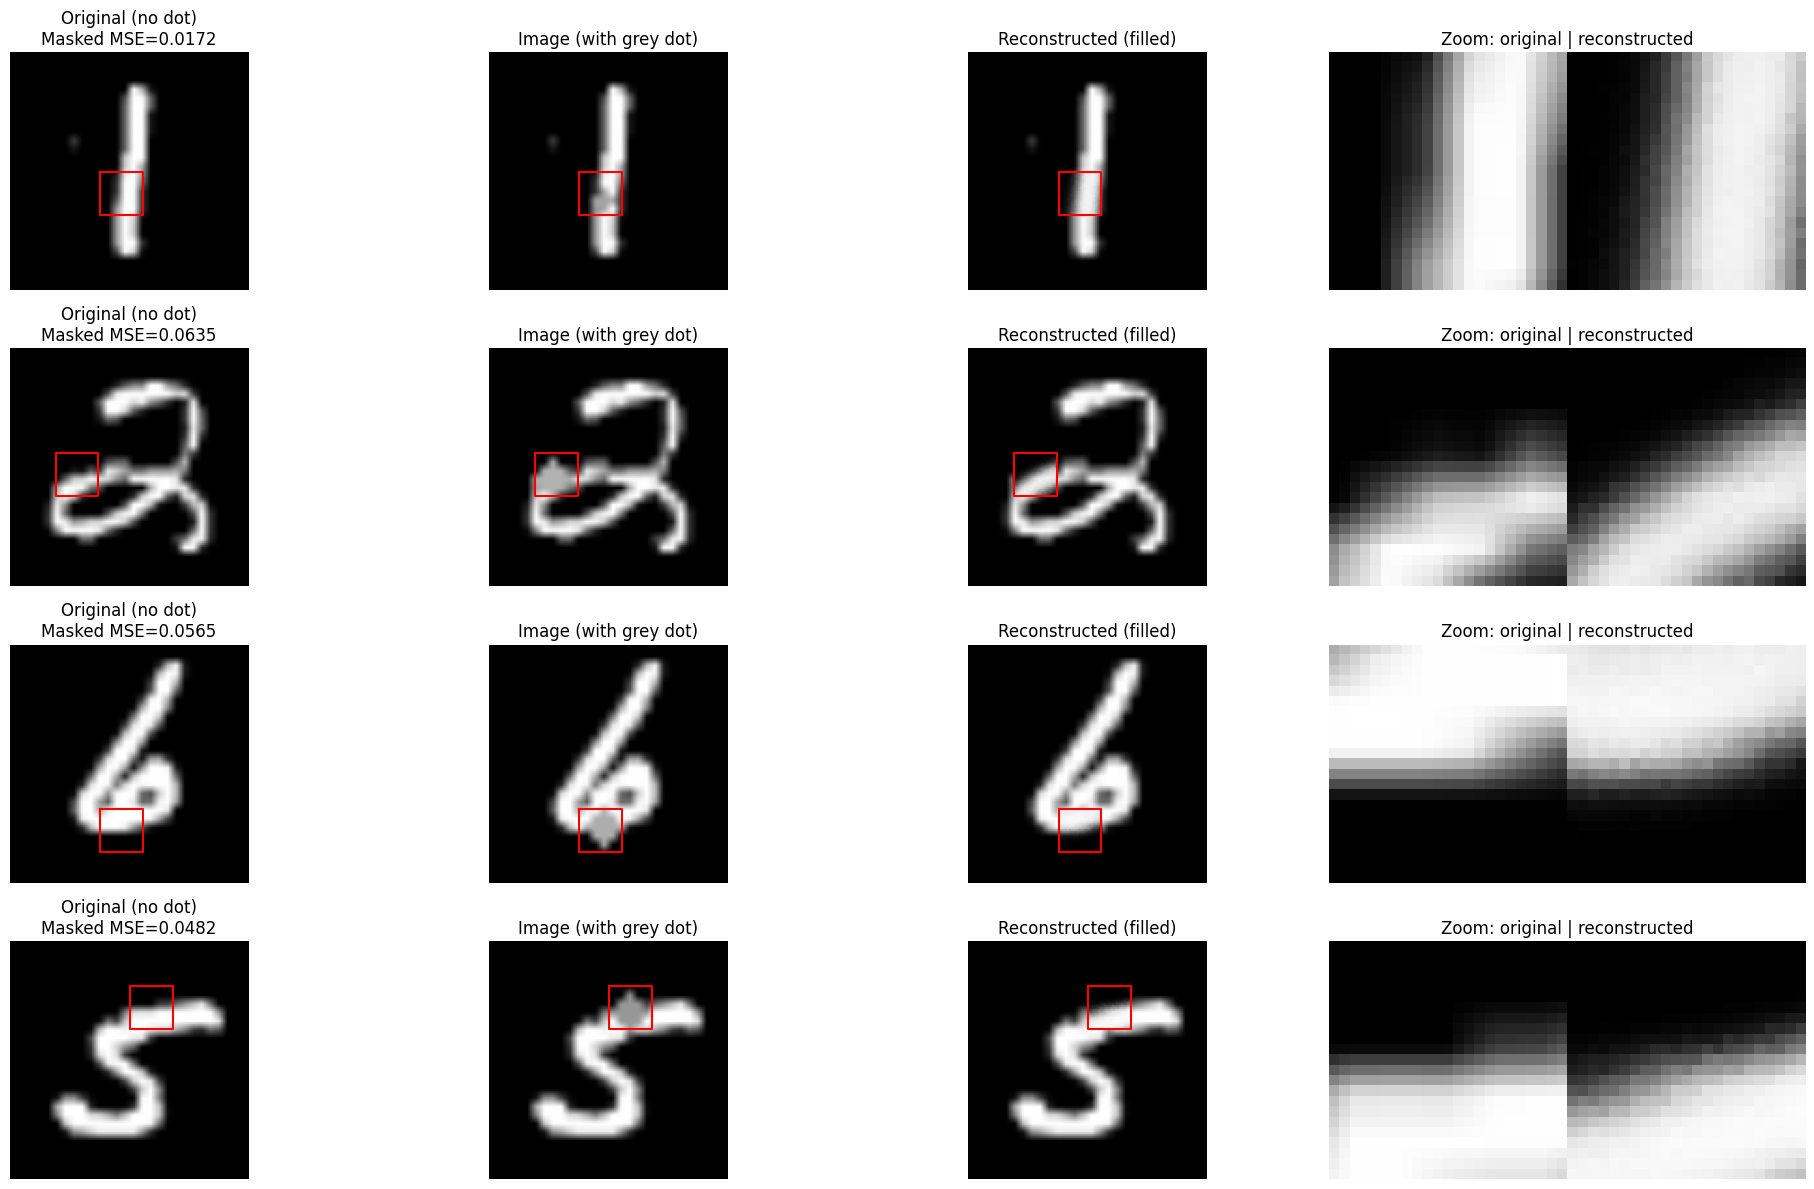

Average masked region MSE: 0.040716


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
masked_mse = evaluate_masked_vae_with_visuals(
    model_copy, test_loader, mask_fn, device=device, patch_size=patch_size, n_show=4
)
